# 3.1 New Embodiment Finetuning Tutorial (Python API)

This provides a step-by-step guide on how to finetune GR00T-N1.5 with our python API, the G1 Block Stacking Dataset is used as an example.

This is a more detailed version of the [3_0_new_embodiment_finetuning.md](3_0_new_embodiment_finetuning.md) tutorial, which explains in-depth the details of configuring the dataset, transforms, and finetuning.


---

## Step 1: Dataset

Loading any dataset for finetuning can be done in 2 steps:
- 1.1: Defining the modality configs and transforms for the dataset
- 1.2: Loading the dataset using the `LeRobotSingleDataset` class

### Step: 1.0 Download the dataset

- Download the dataset from: https://huggingface.co/datasets/unitreerobotics/G1_BlockStacking_Dataset
- copy over the `examples/unitree_g1_blocks__modality.json` to the dataset `<DATASET_PATH>/meta/modality.json`
  - This provides additional information about the state and action modalities to make it "GR00T-compatible"
  - `cp examples/unitree_g1_blocks__modality.json datasets/G1_BlockStacking_Dataset/meta/modality.json`


**Understanding the Modality Configs**

This file provides detailed metadata about state and action modalities, enabling:

- **Separate Data Storage and Interpretation:**
  - **State and Action:** Stored as concatenated float32 arrays. The `modality.json` file supplies the metadata necessary to interpret these arrays as distinct, fine-grained fields with additional training information.
  - **Video:** Stored as separate files, with the configuration file allowing them to be renamed to a standardized format.
  - **Annotations:** Keeps track of all annotation fields. If there are no annotations, do not include the `annotation` field in the configuration file.
- **Fine-Grained Splitting:** Divides the state and action arrays into more semantically meaningful fields.
- **Clear Mapping:** Explicit mapping of data dimensions.
- **Sophisticated Data Transformations:** Supports field-specific normalization and rotation transformations during training.

#### Schema

```json
{
    "state": {
        "<state_name>": {
            "start": <int>,         // Starting index in the state array
            "end": <int>,           // Ending index in the state array
        }
    },
    "action": {
        "<action_name>": {
            "start": <int>,         // Starting index in the action array
            "end": <int>,           // Ending index in the action array
        }
    },
    "video": {
        "<video_name>": {}  // Empty dictionary to maintain consistency with other modalities
    },
    "annotation": {
        "<annotation_name>": {}  // Empty dictionary to maintain consistency with other modalities
    }
}
```

Example is shown in `getting_started/examples/unitree_g1_blocks__modality.json`. This file is located in the `meta` folder of the lerobot dataset.


Generate the Stats (`meta/metadata.json`) by running the following command:
```bash
python scripts/load_dataset.py --data_path /datasets/G1_BlockStacking_Dataset/ --embodiment_tag new_embodiment
```

In [1]:
from gr00t.data.schema import EmbodimentTag

In [13]:
dataset_path = "/data/gjx/Humanoid/leju_data_final"  # change this to your dataset path
embodiment_tag = EmbodimentTag.NEW_EMBODIMENT

In [14]:
# Multi-task helper: if dataset_path is a base directory containing multiple tasks,
# automatically build a LeRobotMixtureDataset from all valid subfolders; otherwise build a single dataset.
from pathlib import Path
from typing import List, Tuple
from gr00t.data.dataset import LeRobotSingleDataset, LeRobotMixtureDataset

TASK_DIR_CANDIDATES = [
    "loadning_of_large_tooling",
    "loadning_of_small_tooling",
    "parts_offline",
    "single_coil_sorting",
    "single_goods_orders",
    "single_scan_code_for_weighing",
    "SPS_parts_sorting",
]

def discover_task_dirs(base: Path) -> List[Path]:
    # Return subdirs that contain a lerobot dataset (meta/ exists and data/ exists)
    found = []
    for name in TASK_DIR_CANDIDATES:
        p = base / name
        if (p / "meta").exists() and (p / "data").exists():
            found.append(p)
    # Fallback: include any subdir that looks like a dataset
    if not found and base.exists():
        for p in base.iterdir():
            if p.is_dir() and (p / "meta").exists() and (p / "data").exists():
                found.append(p)
    return found

def build_dataset(dataset_path: str, modality_configs, embodiment_tag, transforms=None, video_backend="torchcodec"):
    base = Path(dataset_path)
    if base.is_dir() and (base / "meta").exists() and (base / "data").exists():
        # Single task directory
        print(f"[builder] Using single-task dataset: {base}")
        return LeRobotSingleDataset(
            dataset_path=base,
            modality_configs=modality_configs,
            embodiment_tag=embodiment_tag,
            transforms=transforms,
            video_backend=video_backend,
        )
    # Try multi-task discovery
    subdirs = discover_task_dirs(base)
    if len(subdirs) == 0:
        raise FileNotFoundError(f"No valid sub-datasets found under {base}. Please check the path.")
    print("[builder] Discovered sub-datasets:")
    for p in subdirs:
        print(" -", p)
    # Build per-task LeRobotSingleDataset and wrap with LeRobotMixtureDataset (equal weights)
    datasets = []
    for p in subdirs:
        ds = LeRobotSingleDataset(
            dataset_path=p,
            modality_configs=modality_configs,
            embodiment_tag=embodiment_tag,
            transforms=transforms,
            video_backend=video_backend,
        )
        datasets.append((ds, 1.0))
    mixture = LeRobotMixtureDataset(datasets, mode="train")
    print("[builder] Built LeRobotMixtureDataset with", len(datasets), "sub-datasets")
    return mixture

In [15]:
# Quick consistency check: modality.json vs stats.json vs parquet shapes
from pathlib import Path
import json
import pandas as pd

# Use the same dataset_path defined above
root = Path(dataset_path)
meta = root / "meta"

print(f"Dataset root: {root}")

# Helper to run the check on a single dataset dir
def run_single_check(root: Path):
    meta = root / "meta"
    print(f"\n=== Checking: {root} ===")
    # 1) Load modality.json and compute expected lengths
    modality_path = meta / "modality.json"
    stats_path = meta / "stats.json"

    def expected_len(mod_section: dict) -> int:
        if not isinstance(mod_section, dict) or not mod_section:
            return 0
        return max(int(v["end"]) for v in mod_section.values())

    modality = {}
    if modality_path.exists():
        try:
            modality = json.loads(modality_path.read_text(encoding="utf-8"))
        except Exception as e:
            print("Failed to read modality.json:", e)
    else:
        print("modality.json not found at", modality_path)

    exp_state = expected_len(modality.get("state", {}))
    exp_action = expected_len(modality.get("action", {}))
    print("Expected observation.state length (from modality.json):", exp_state)
    print("Expected action length (from modality.json):", exp_action)

    # 2) Load stats.json and read actual array lengths
    stats = {}
    if stats_path.exists():
        try:
            stats = json.loads(stats_path.read_text(encoding="utf-8"))
        except Exception as e:
            print("Failed to read stats.json:", e)
    else:
        print("stats.json not found at", stats_path)

    def stat_len(stats_section: dict) -> int:
        if not isinstance(stats_section, dict) or not stats_section:
            return 0
        for k in ["min", "max", "mean", "std", "q01", "q99"]:
            if k in stats_section and isinstance(stats_section[k], list):
                return len(stats_section[k])
        return 0

    len_state_stat = stat_len(stats.get("observation.state", {}))
    len_action_stat = stat_len(stats.get("action", {}))
    print("Actual observation.state stat length (from stats.json):", len_state_stat)
    print("Actual action stat length (from stats.json):", len_action_stat)

    # 3) Inspect first parquet to get real column lengths
    import itertools
    parquet_files = sorted((root / "data").rglob("*.parquet"))
    state_len_sample = None
    action_len_sample = None
    first_file = None
    if parquet_files:
        first_file = parquet_files[0]
        try:
            df = pd.read_parquet(first_file)
            if "observation.state" in df.columns and len(df) > 0:
                try:
                    v = df["observation.state"].iloc[0]
                    state_len_sample = len(v) if hasattr(v, "__len__") else None
                except Exception:
                    state_len_sample = None
            if "action" in df.columns and len(df) > 0:
                try:
                    v = df["action"].iloc[0]
                    action_len_sample = len(v) if hasattr(v, "__len__") else None
                except Exception:
                    action_len_sample = None
        except Exception as e:
            print("Failed to read parquet:", first_file, e)

    print("First parquet file:", first_file)
    print("Sampled observation.state length (from parquet):", state_len_sample)
    print("Sampled action length (from parquet):", action_len_sample)

    # 4) If mismatch, identify offending segments
    if len_state_stat and exp_state and exp_state > len_state_stat:
        bad = []
        for name, seg in modality.get("state", {}).items():
            if int(seg["end"]) > len_state_stat:
                bad.append((name, seg))
        print("State segments exceeding stats length:", bad)

    if len_action_stat and exp_action and exp_action > len_action_stat:
        bad = []
        for name, seg in modality.get("action", {}).items():
            if int(seg["end"]) > len_action_stat:
                bad.append((name, seg))
        print("Action segments exceeding stats length:", bad)

    print("\nHint:")
    print("- If Expected != Actual, either recompute stats.json (recommended) or fix modality.json to match actual shapes.")
    print("- To recompute stats: run 'python scripts/load_dataset.py --data_path <dataset> --embodiment_tag new_embodiment' from repo root.")

# Detect multi-task: if root has meta/, treat as single; otherwise check subdirs
if (root / "meta").exists() and (root / "data").exists():
    run_single_check(root)
else:
    # try to discover sub-datasets
    from pathlib import Path as _P
    base = _P(dataset_path)
    subdirs = []
    for p in base.iterdir():
        if p.is_dir() and (p / "meta").exists() and (p / "data").exists():
            subdirs.append(p)
    if not subdirs:
        print("No valid sub-datasets found under:", base)
    else:
        print("Found", len(subdirs), "sub-datasets. Running checks...")
        for p in subdirs:
            run_single_check(p)

Dataset root: /data/gjx/Humanoid/leju_data_final
Found 7 sub-datasets. Running checks...

=== Checking: /data/gjx/Humanoid/leju_data_final/SPS_parts_sorting ===
Expected observation.state length (from modality.json): 40
Expected action length (from modality.json): 40
stats.json not found at /data/gjx/Humanoid/leju_data_final/SPS_parts_sorting/meta/stats.json
Actual observation.state stat length (from stats.json): 0
Actual action stat length (from stats.json): 0
First parquet file: /data/gjx/Humanoid/leju_data_final/SPS_parts_sorting/data/chunk-000/episode_000000.parquet
Sampled observation.state length (from parquet): 40
Sampled action length (from parquet): 40

Hint:
- If Expected != Actual, either recompute stats.json (recommended) or fix modality.json to match actual shapes.
- To recompute stats: run 'python scripts/load_dataset.py --data_path <dataset> --embodiment_tag new_embodiment' from repo root.

=== Checking: /data/gjx/Humanoid/leju_data_final/parts_offline ===
Expected obser

### Step: 1.1 Modality configs and transforms

Modality configs let you select which specific data streams to use for each input type (video, state, action, language, etc.) during finetuning, giving you precise control over which parts of your dataset are utilized.

In [4]:
# # Fix modality.json to match actual 26-d state/action vectors
# from pathlib import Path
# import json

# root = Path(dataset_path)
# meta = root / "meta"
# modality_path = meta / "modality.json"

# # Define a 26-d split: 7+7 arms + 6+6 legs (adjust here if your true layout differs)
# fixed_modality = {
#     "state": {
#          "left_arm": {"start": 0, "end": 7},
#          "right_arm": {"start": 7, "end": 14},
#          "left_leg": {"start": 14, "end": 20},
#          "right_leg": {"start": 20, "end": 26},
#     },
#      "action": {
#          "left_arm": {"start": 0, "end": 7},
#          "right_arm": {"start": 7, "end": 14},
#          "left_leg": {"start": 14, "end": 20},
#          "right_leg": {"start": 20, "end": 26},
#     },
#     "video": {
#         # keep your original mapping
#         "ego_view": {"original_key": "observation.images.head_cam_h"},
#         "left_hand_camera": {"original_key": "observation.images.wrist_cam_l"},
#         "right_hand_camera": {"original_key": "observation.images.wrist_cam_r"},
#     },
#     "annotation": {
#         "human.action.task_description": {},
#         "human.validity": {},
#         "human.coarse_action": {"original_key": "annotation.human.action.task_description"},
#     },
# }

# # Backup old file
# if modality_path.exists():
#     (meta / "modality.backup.json").write_text(modality_path.read_text(encoding="utf-8"), encoding="utf-8")

# # Write new modality
# modality_path.write_text(json.dumps(fixed_modality, ensure_ascii=False, indent=2), encoding="utf-8")
# print("modality.json updated. Backup saved to meta/modality.backup.json")

In [16]:
from gr00t.data.dataset import ModalityConfig


# select the modality keys you want to use for finetuning
video_modality = ModalityConfig(
    delta_indices=[0],
    modality_keys=["video.ego_view", "video.left_hand_camera", "video.right_hand_camera"],
)

state_modality = ModalityConfig(
    delta_indices=[0],
    modality_keys=["state.left_arm", "state.right_arm", "state.left_hand", "state.right_hand"],
)

action_modality = ModalityConfig(
    delta_indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    modality_keys=["action.left_arm", "action.right_arm", "action.left_hand", "action.right_hand"],
)

language_modality = ModalityConfig(
     delta_indices=[0],
     modality_keys=["annotation.human.action.task_description"],
 )

modality_configs = {
    "video": video_modality,
    "state": state_modality,
    "action": action_modality,
    "language": language_modality,
}

In [17]:
from gr00t.data.transform.base import ComposedModalityTransform
from gr00t.data.transform import VideoToTensor, VideoCrop, VideoResize, VideoColorJitter, VideoToNumpy
from gr00t.data.transform.state_action import StateActionToTensor, StateActionTransform
from gr00t.data.transform.concat import ConcatTransform
from gr00t.model.transforms import GR00TTransform


# select the transforms you want to apply to the data
to_apply_transforms = ComposedModalityTransform(
    transforms=[
        # video transforms
        VideoToTensor(apply_to=video_modality.modality_keys, backend="torchvision"),
        VideoCrop(apply_to=video_modality.modality_keys, scale=0.95, backend="torchvision"),
        VideoResize(apply_to=video_modality.modality_keys, height=224, width=224, interpolation="linear", backend="torchvision" ),
        VideoColorJitter(apply_to=video_modality.modality_keys, brightness=0.3, contrast=0.4, saturation=0.5, hue=0.08, backend="torchvision"),
        VideoToNumpy(apply_to=video_modality.modality_keys),

        # state transforms
        StateActionToTensor(apply_to=state_modality.modality_keys),
        StateActionTransform(apply_to=state_modality.modality_keys, normalization_modes={
            "state.left_arm": "min_max",
            "state.right_arm": "min_max",
            "state.left_hand": "min_max",
            "state.right_hand": "min_max",
        }),

        # action transforms
        StateActionToTensor(apply_to=action_modality.modality_keys),
        StateActionTransform(apply_to=action_modality.modality_keys, normalization_modes={
            "action.right_arm": "min_max",
            "action.left_arm": "min_max",
            "action.right_hand": "min_max",
            "action.left_hand": "min_max",
        }),

        # ConcatTransform
        ConcatTransform(
            video_concat_order=video_modality.modality_keys,
            state_concat_order=state_modality.modality_keys,
            action_concat_order=action_modality.modality_keys,
        ),
        # model-specific transform
        GR00TTransform(
            state_horizon=len(state_modality.delta_indices),
            action_horizon=len(action_modality.delta_indices),
            max_state_dim=64,
            max_action_dim=32,
        ),
    ]
)


### Step 1.2 Load the dataset

First we will visualize the dataset and then load it using the `LeRobotSingleDataset` class. (without transforms)

In [18]:
from gr00t.data.dataset import LeRobotSingleDataset

# Use the builder to support single-task or multi-task automatically
train_dataset = build_dataset(
    dataset_path=dataset_path,
    modality_configs=modality_configs,
    embodiment_tag=embodiment_tag,
    transforms=None,
    video_backend="torchcodec",
)


[builder] Discovered sub-datasets:
 - /data/gjx/Humanoid/leju_data_final/loadning_of_large_tooling
 - /data/gjx/Humanoid/leju_data_final/loadning_of_small_tooling
 - /data/gjx/Humanoid/leju_data_final/parts_offline
 - /data/gjx/Humanoid/leju_data_final/single_coil_sorting
 - /data/gjx/Humanoid/leju_data_final/single_goods_orders
 - /data/gjx/Humanoid/leju_data_final/single_scan_code_for_weighing
 - /data/gjx/Humanoid/leju_data_final/SPS_parts_sorting
Failed to load dataset statistics: [Errno 2] No such file or directory: '/data/gjx/Humanoid/leju_data_final/loadning_of_large_tooling/meta/stats.json'
Calculating dataset statistics for loadning_of_large_tooling


Computing statistics for action.head.position...
Computing statistics for action.joint.position...
Computing statistics for action.joint.position...
Computing statistics for action.leg.position...
Computing statistics for action.leg.position...
Computing statistics for state.head.effort...
Computing statistics for state.head.effort...
Computing statistics for state.head.position...
Computing statistics for state.head.position...
Computing statistics for state.head.velocity...
Computing statistics for state.head.velocity...
Computing statistics for state.joint.current_value...
Computing statistics for state.joint.current_value...
Computing statistics for state.joint.effort...
Computing statistics for state.joint.effort...
Computing statistics for state.joint.position...
Computing statistics for state.joint.position...
Computing statistics for state.joint.velocity...
Computing statistics for state.joint.velocity...
Computing statistics for state.robot.orientation...
Computing statistics 

Computing statistics for action.head.position...
Computing statistics for action.joint.position...
Computing statistics for action.joint.position...
Computing statistics for action.leg.position...
Computing statistics for action.leg.position...
Computing statistics for state.head.effort...
Computing statistics for state.head.effort...
Computing statistics for state.head.position...
Computing statistics for state.head.position...
Computing statistics for state.head.velocity...
Computing statistics for state.head.velocity...
Computing statistics for state.joint.current_value...
Computing statistics for state.joint.current_value...
Computing statistics for state.joint.effort...
Computing statistics for state.joint.effort...
Computing statistics for state.joint.position...
Computing statistics for state.joint.position...
Computing statistics for state.joint.velocity...
Computing statistics for state.joint.velocity...
Computing statistics for state.robot.orientation...
Computing statistics 

Computing statistics for action.head.position...
Computing statistics for action.joint.position...
Computing statistics for action.joint.position...
Computing statistics for action.leg.position...
Computing statistics for action.leg.position...
Computing statistics for state.head.effort...
Computing statistics for state.head.effort...
Computing statistics for state.head.position...
Computing statistics for state.head.position...
Computing statistics for state.head.velocity...
Computing statistics for state.head.velocity...
Computing statistics for state.joint.current_value...
Computing statistics for state.joint.current_value...
Computing statistics for state.joint.effort...
Computing statistics for state.joint.effort...
Computing statistics for state.joint.position...
Computing statistics for state.joint.position...
Computing statistics for state.joint.velocity...
Computing statistics for state.joint.velocity...
Computing statistics for state.robot.orientation...
Computing statistics 

Computing statistics for action.head.position...
Computing statistics for action.joint.position...
Computing statistics for action.leg.position...
Computing statistics for state.head.effort...
Computing statistics for state.head.position...
Computing statistics for state.head.velocity...
Computing statistics for state.joint.current_value...
Computing statistics for state.head.effort...
Computing statistics for state.head.position...
Computing statistics for state.head.velocity...
Computing statistics for state.joint.current_value...
Computing statistics for state.joint.effort...
Computing statistics for state.joint.position...
Computing statistics for state.joint.velocity...
Computing statistics for state.joint.effort...
Computing statistics for state.joint.position...
Computing statistics for state.joint.velocity...
Computing statistics for state.robot.orientation...
Computing statistics for state.leg.current_value...
Computing statistics for state.leg.effort...
Computing statistics f

Computing statistics for action.head.position...
Computing statistics for action.joint.position...
Computing statistics for action.leg.position...
Computing statistics for state.head.effort...
Computing statistics for action.leg.position...
Computing statistics for state.head.effort...
Computing statistics for state.head.position...
Computing statistics for state.head.velocity...
Computing statistics for state.joint.current_value...
Computing statistics for state.head.position...
Computing statistics for state.head.velocity...
Computing statistics for state.joint.current_value...
Computing statistics for state.joint.effort...
Computing statistics for state.joint.position...
Computing statistics for state.joint.effort...
Computing statistics for state.joint.position...
Computing statistics for state.joint.velocity...
Computing statistics for state.robot.orientation...
Computing statistics for state.joint.velocity...
Computing statistics for state.robot.orientation...
Computing statistic

Computing statistics for action.head.position...
Computing statistics for action.joint.position...
Computing statistics for action.joint.position...
Computing statistics for action.leg.position...
Computing statistics for action.leg.position...
Computing statistics for state.head.effort...
Computing statistics for state.head.effort...
Computing statistics for state.head.position...
Computing statistics for state.head.position...
Computing statistics for state.head.velocity...
Computing statistics for state.head.velocity...
Computing statistics for state.joint.current_value...
Computing statistics for state.joint.current_value...
Computing statistics for state.joint.effort...
Computing statistics for state.joint.effort...
Computing statistics for state.joint.position...
Computing statistics for state.joint.position...
Computing statistics for state.joint.velocity...
Computing statistics for state.joint.velocity...
Computing statistics for state.robot.orientation...
Computing statistics 

dict_keys(['video.ego_view', 'video.left_hand_camera', 'video.right_hand_camera', 'state.left_arm', 'state.right_arm', 'state.left_hand', 'state.right_hand', 'action.left_arm', 'action.right_arm', 'action.left_hand', 'action.right_hand', 'annotation.human.action.task_description'])


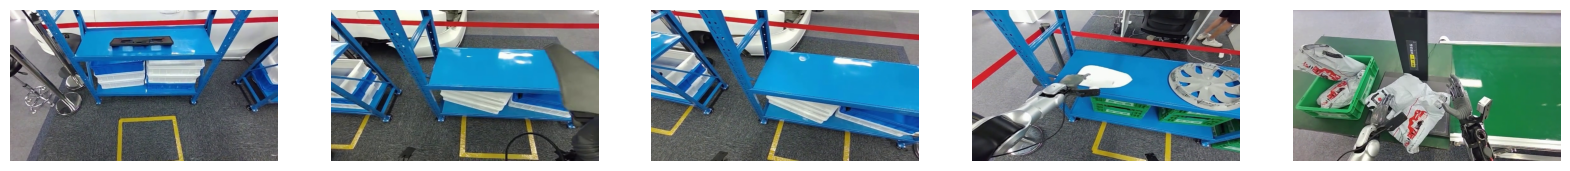

In [19]:
# use matplotlib to visualize the images
import matplotlib.pyplot as plt
import numpy as np

print(train_dataset[0].keys())

images = []
for i in range(5):
    image = train_dataset[i]["video.ego_view"][0]
    # image is in HWC format, convert it to CHW format
    image = image.transpose(2, 0, 1)
    images.append(image)   

fig, axs = plt.subplots(1, 5, figsize=(20, 5))
for i, image in enumerate(images):
    axs[i].imshow(np.transpose(image, (1, 2, 0)))
    axs[i].axis("off")
plt.show()

Now, we will initiate a dataset with our modality configs and transforms.

In [20]:
train_dataset = build_dataset(
    dataset_path=dataset_path,
    modality_configs=modality_configs,
    embodiment_tag=embodiment_tag,
    transforms=to_apply_transforms,
    video_backend="torchcodec",        # 或者 "decord" / "opencv"
)

[builder] Discovered sub-datasets:
 - /data/gjx/Humanoid/leju_data_final/loadning_of_large_tooling
 - /data/gjx/Humanoid/leju_data_final/loadning_of_small_tooling
 - /data/gjx/Humanoid/leju_data_final/parts_offline
 - /data/gjx/Humanoid/leju_data_final/single_coil_sorting
 - /data/gjx/Humanoid/leju_data_final/single_goods_orders
 - /data/gjx/Humanoid/leju_data_final/single_scan_code_for_weighing
 - /data/gjx/Humanoid/leju_data_final/SPS_parts_sorting
Initialized dataset loadning_of_large_tooling with EmbodimentTag.NEW_EMBODIMENT
Initialized dataset loadning_of_small_tooling with EmbodimentTag.NEW_EMBODIMENT
Initialized dataset parts_offline with EmbodimentTag.NEW_EMBODIMENT
Initialized dataset single_coil_sorting with EmbodimentTag.NEW_EMBODIMENT
Initialized dataset single_goods_orders with EmbodimentTag.NEW_EMBODIMENT
Initialized dataset single_scan_code_for_weighing with EmbodimentTag.NEW_EMBODIMENT
Initialized dataset SPS_parts_sorting with EmbodimentTag.NEW_EMBODIMENT
[builder] Bui

**Extra Notes**:
 - We use a cached dataloader to accelerate training speed. The cached dataloader loads all data into memory, which significantly improves training performance. However, if your dataset is large or you're experiencing out-of-memory (OOM) errors, you can switch to the standard lerobot dataloader (`gr00t.data.dataset.LeRobotSingleDataset`). It uses the same API as the cached dataloader, so you can switch back and forth without any changes to your code.
 - we use `torchcodec` as the video backend, the video encoding is in av instead of standard h264


### Step 2: Load the model

The training process is done in 3 steps:
- 2.1: Load the base model from HuggingFace or a local path
- 2.2: Prepare training args
- 2.3: Run the training loop

#### Step 2.1 Load the base model

We'll use the `from_pretrained_for_tuning` method to load the model. This method allows us to specify which parts of the model to tune.

In [21]:
import os
import torch
os.environ["CUDA_VISIBLE_DEVICES"] = "0,3"
device = "cuda" if torch.cuda.is_available() else "cpu"

In [22]:
from gr00t.model.gr00t_n1 import GR00T_N1_5

BASE_MODEL_PATH = "nvidia/GR00T-N1.5-3B"
TUNE_LLM = False            # Whether to tune the LLM
TUNE_VISUAL = False          # Whether to tune the visual encoder
TUNE_PROJECTOR = True       # Whether to tune the projector
TUNE_DIFFUSION_MODEL = True # Whether to tune the diffusion model

model = GR00T_N1_5.from_pretrained(
    pretrained_model_name_or_path=BASE_MODEL_PATH,
    tune_llm=TUNE_LLM,  # backbone's LLM
    tune_visual=TUNE_VISUAL,  # backbone's vision tower
    tune_projector=TUNE_PROJECTOR,  # action head's projector
    tune_diffusion_model=TUNE_DIFFUSION_MODEL,  # action head's DiT
)

# Set the model's compute_dtype to bfloat16
model.compute_dtype = "bfloat16"
model.config.compute_dtype = "bfloat16"
model.to(device)

Loading pretrained dual brain from nvidia/GR00T-N1.5-3B
Tune backbone vision tower: False
Tune backbone LLM: False
Tune action head projector: True
Tune action head DiT: True


Fetching 13 files: 100%|██████████| 13/13 [00:00<00:00, 88229.70it/s]



Tune backbone llm: False
Tune backbone visual: True
Total number of DiT parameters:  550386688
Total number of SelfAttentionTransformer parameters:  201433088
Tune action head projector: True
Tune action head diffusion model: True
Total number of SelfAttentionTransformer parameters:  201433088
Tune action head projector: True
Tune action head diffusion model: True


Loading checkpoint shards: 100%|██████████| 3/3 [00:21<00:00,  7.20s/it]



Tune backbone llm: False
Tune backbone visual: False
Tune action head projector: True
Tune action head diffusion model: True


GR00T_N1_5(
  (backbone): EagleBackbone(
    (eagle_model): Eagle2_5_VLForConditionalGeneration(
      (vision_model): SiglipVisionModel(
        (vision_model): SiglipVisionTransformer(
          (embeddings): SiglipVisionEmbeddings(
            (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
            (position_embedding): Embedding(256, 1152)
          )
          (encoder): SiglipEncoder(
            (layers): ModuleList(
              (0-26): 27 x SiglipEncoderLayer(
                (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
                (self_attn): SiglipAttention(
                  (k_proj): Linear(in_features=1152, out_features=1152, bias=True)
                  (v_proj): Linear(in_features=1152, out_features=1152, bias=True)
                  (q_proj): Linear(in_features=1152, out_features=1152, bias=True)
                  (out_proj): Linear(in_features=1152, out_features=1152, bias=True)
              

#### Step 2.2 Prepare training args

We use huggingface `TrainingArguments` to configure the training process. Here are the main parameters:

In [23]:
from transformers import TrainingArguments

output_dir = "output/model/path"    # CHANGE THIS ACCORDING TO YOUR LOCAL PATH
per_device_train_batch_size = 8     # CHANGE THIS ACCORDING TO YOUR GPU MEMORY
max_steps = 20                      # CHANGE THIS ACCORDING TO YOUR NEEDS
report_to = "wandb"
dataloader_num_workers = 8

training_args = TrainingArguments(
    output_dir=output_dir,
    run_name=None,
    remove_unused_columns=False,
    deepspeed="",
    gradient_checkpointing=False,
    bf16=True,
    tf32=True,
    per_device_train_batch_size=per_device_train_batch_size,
    gradient_accumulation_steps=1,
    dataloader_num_workers=dataloader_num_workers,
    dataloader_pin_memory=False,
    dataloader_persistent_workers=True,
    optim="adamw_torch",
    adam_beta1=0.95,
    adam_beta2=0.999,
    adam_epsilon=1e-8,
    learning_rate=1e-4,
    weight_decay=1e-5,
    warmup_ratio=0.05,
    lr_scheduler_type="cosine",
    logging_steps=10.0,
    num_train_epochs=300,
    max_steps=max_steps,
    save_strategy="steps",
    save_steps=500,
    save_total_limit=8,
    report_to=report_to,
    seed=42,
    do_eval=False,
    ddp_find_unused_parameters=False,
    ddp_bucket_cap_mb=100,
    torch_compile_mode=None,
)


#### Step 2.3 Initialize the training runner and run the training loop

In [ ]:

from gr00t.experiment.runner import TrainRunner

experiment = TrainRunner(
    train_dataset=train_dataset,
    model=model,
    training_args=training_args,
)



experiment.train()

Run name: output/model/path
train dataloader length: 79327
train dataset length: 1269219
GPU memory before training: 7.076685905456543 GB
train dataloader length: 79327
train dataset length: 1269219
GPU memory before training: 7.076685905456543 GB
TensorBoard logs will be saved to: output/model/path/runs
TensorBoard logs will be saved to: output/model/path/runs


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

We can see the 1k offline validation results vs 10k offline validation results:

**Finetuning Results on Unitree G1 Block Stacking Dataset:**

| 1k Steps | 10k Steps |
| --- | --- |
| ![1k](../media/g1_ft_1k.png) | ![10k](../media/g1_ft_10k.png) |
| MSE: 0.0181 | MSE: 0.0022 |